In [1]:
!pip install git+https://github.com/RocketPy-Team/RocketPy.git@develop


  Cloning https://github.com/RocketPy-Team/RocketPy.git (to revision develop) to c:\users\wesle\appdata\local\temp\pip-req-build-ak3112j1


  ERROR: Error [WinError 2] O sistema não pode encontrar o arquivo especificado while executing command git version

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Cannot find command 'git' - do you have 'git' installed and in your PATH?


In [2]:
from rocketpy import Environment, Flight, Rocket, SolidMotor

In [3]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [4]:
# Configura as condições do local e data de lançamento
env = Environment(
    latitude=-21.90795,          # Latitude do local de lançamento (em graus decimais)
    longitude=-48.96156,         # Longitude do local de lançamento (em graus decimais)
    elevation=495            # Altitude do local de lançamento (em metros)
)

In [5]:
from datetime import datetime, timedelta
from rocketpy import Environment

tomorrow = datetime.now() + timedelta(days=1)

env.set_date(
    (tomorrow.year, tomorrow.month, tomorrow.day, 12)
)  # Hora em UTC

c:\Users\wesle\AppData\Local\Programs\Python\Python313\Lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2026-03-25 03:00:00 UTC instead.
  warnings.warn(


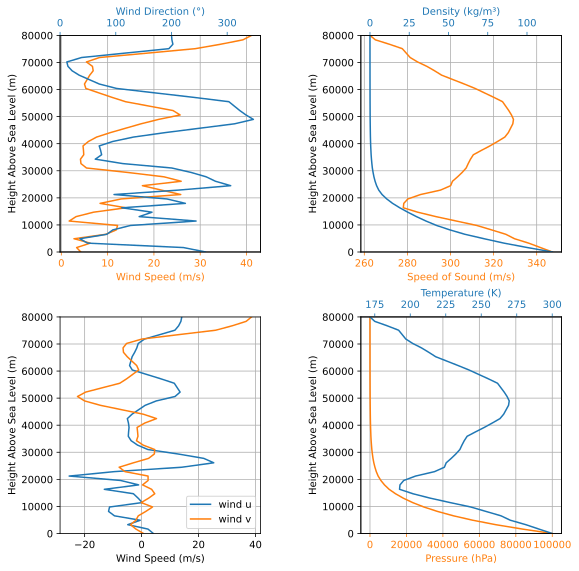

In [6]:

env_gfs = Environment(date=tomorrow)
    
env_gfs.set_atmospheric_model(type="forecast", file="GFS")

env_gfs.plots.atmospheric_model()


Gravity Details

Acceleration of gravity at surface level:    9.7803 m/s²
Acceleration of gravity at  78.995 km (ASL): 9.5409 m/s²


Launch Site Details

Launch Date: 2026-03-25 02:01:05 UTC
Launch Site Latitude: 0.00000°
Launch Site Longitude: 0.00000°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 166021.44 W|E    0.00 N
Launch Site UTM zone: 31N
Launch Site Surface Elevation: 0.1 m


Atmospheric Model Details

Atmospheric Model Type: forecast
forecast Maximum Height: 78.995 km

Surface Atmospheric Conditions

Surface Wind Speed: 4.19 m/s
Surface Wind Direction: 260.88°
Surface Wind Heading: 80.88°
Surface Pressure: 100000.00 hPa
Surface Temperature: 300.04 K
Surface Air Density: 116.107 kg/m³
Surface Speed of Sound: 347.24 m/s


Earth Model Details

Earth Radius at Launch site: 6378.14 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



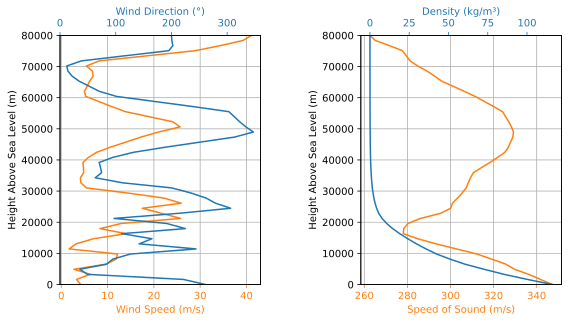

In [7]:
env_gfs.info()

In [8]:
# %%
# ------------------------- MOTOR -------------------------
from rocketpy import SolidMotor

FalconOne = SolidMotor(
    # Fonte da curva de empuxo
    thrust_source="FalconOneV1.eng",

    # Tempo de queima em segundos
    burn_time=1.4,

    # Massa do motor vazio (975.00 g -> 0.975 kg)
    dry_mass=0.975,

    # Inércia do motor vazio (convertida de g*mm² para kg*m²)(Ixx, Iyy, Izz)
    dry_inertia=(1.0047, 0.9756, 0.0298),

    # Centro de massa seco do motor no seu sistema (origem no bocal)
    center_of_dry_mass_position=0.10,

    # Posição da saída do bocal (origem do sistema do motor)
    nozzle_position=0.0,

    # Raio da SAÍDA do bocal (12.6 mm -> 0.0126 m)
    nozzle_radius=0.0126,

    # Raio da GARGANTA do bocal (4.9 mm -> 0.0049 m)
    throat_radius=0.0049,

    # Número de grãos de propelente
    grain_number=3,
    
    # Densidade do propelente em kg/m³
    grain_density=2050,
    
    # Raio externo do grão (21 mm -> 0.021 m)
    grain_outer_radius=0.021,
    
    # Raio interno inicial do grão (8.9 mm -> 0.0089 m)
    grain_initial_inner_radius=0.0089,
    
    # Altura/comprimento de um grão (80 mm -> 0.080 m)
    grain_initial_height=0.080,
    
    # Separação entre os grãos (0.5 mm -> 0.0005 m)
    grain_separation=0.0005,
    
    # Posição do centro de massa dos grãos (no sistema do motor)
    grains_center_of_mass_position=0.18,

    # Orientação do sistema de coordenadas do motor
    coordinate_system_orientation="nozzle_to_combustion_chamber"
)



Nozzle Details
Nozzle Radius: 0.0126 m
Nozzle Throat Radius: 0.0049 m

Grain Details
Number of Grains: 3
Grain Spacing: 0.0005 m
Grain Density: 2050 kg/m3
Grain Outer Radius: 0.021 m
Grain Inner Radius: 0.0089 m
Grain Height: 0.08 m
Grain Volume: 0.000 m3
Grain Mass: 0.186 kg

Motor Details
Total Burning Time: 1.4 s
Total Propellant Mass: 0.559 kg
Structural Mass Ratio: 0.636
Average Propellant Exhaust Velocity: 1253.043 m/s
Average Thrust: 500.506 N
Maximum Thrust: 536.822 N at 1.11 s after ignition.
Total Impulse: 700.709 Ns



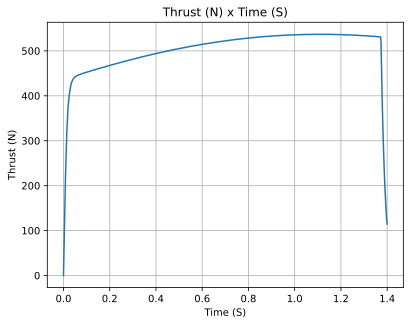

In [9]:
# Imprime um resumo completo do motor para verificar se todos os dados foram carregados corretamente
FalconOne.info()


In [10]:
# ------------------------- FOGUETE -------------------------
from rocketpy import Rocket

FalconOneRocket = Rocket(
    # Raio do foguete (diâmetro máx. 7,96 cm -> raio 0,0398 m)
    radius=0.0398,

    # Massa do foguete SEM o motor (2851 g -> 2.851 kg)
    mass=2.851,

    # Inércia do foguete (Ixx, Iyy, Izz) em kg*m^2
    inertia=(0.499, 0.499, 0.004),

    # Arquivo com a curva de arrasto com motor desligado
    power_off_drag='OffCurvadeArrasto.csv',

    # Arquivo com a curva de arrasto com motor ligado
    power_on_drag='OnCurvadeArrasto.csv',

    # Posição do centro de massa sem o motor (74 cm -> 0,74 m)
    # Medido a partir da ponta da ogiva (ponta do foguete)
    center_of_mass_without_motor=0.74,

    coordinate_system_orientation="nose_to_tail"
)

In [11]:

# A 'position' é a distância (em metros) da ponta da ogiva até a saída do bocal do motor.
FalconOneRocket.add_motor(FalconOne, position=1.41)

In [12]:
# Adiciona a Ogiva ao foguete
ogiva = FalconOneRocket.add_nose(
    length=0.237,       # Comprimento da ogiva em metros
    kind='powerseries',  # Parabólica (OpenRocket)
    power=1.0,
    position=0        # A ponta da ogiva é a origem (0) do foguete
)

# Adiciona as Aletas ao foguete
aletas = FalconOneRocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.08,
    tip_chord=0.03,
    span=0.115,
    position=1.26,
    cant_angle=0,
)

# Adiciona uma Cauda/Transição
cauda = FalconOneRocket.add_tail(
    top_radius=0.0398,   # 5 cm de diâmetro
    bottom_radius=0.025,  # 7.96 cm de diâmetro (raio do corpo)
    length=0.06,
    position=1.36
)


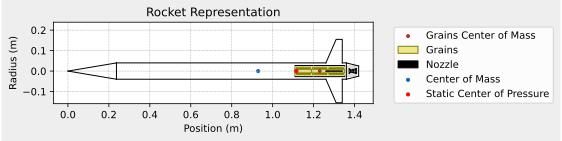

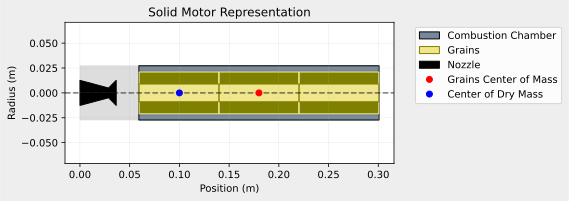

In [13]:
# Verificando a representação do foguete
FalconOneRocket.plots.draw()
FalconOne.plots.draw()



Inertia Details

Rocket Mass: 2.851 kg (without motor)
Rocket Dry Mass: 3.826 kg (with unloaded motor)
Rocket Loaded Mass: 4.385 kg
Rocket Structural Mass Ratio: 0.872
Rocket Inertia (with unloaded motor) 11: 1.740 kg*m2
Rocket Inertia (with unloaded motor) 22: 1.711 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.034 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0398 m
Rocket Frontal Area: 0.004976 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.145 m
Rocket Center of Dry Mass - Nozzle Exit: 0.525 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.345 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.044 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 12.488/rad
Tail Lift Coefficient Deri

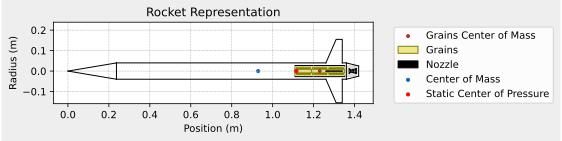


Mass Plots
----------------------------------------


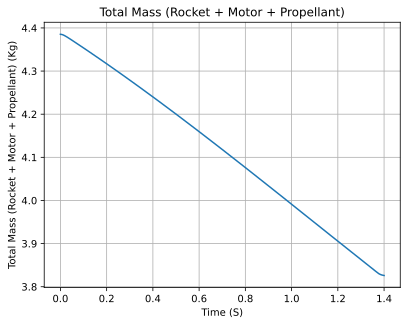

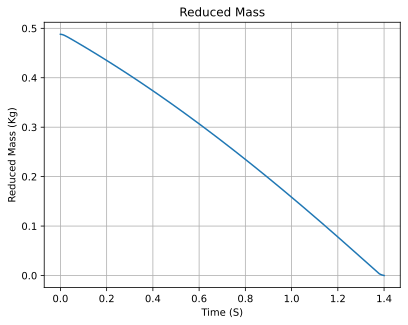


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


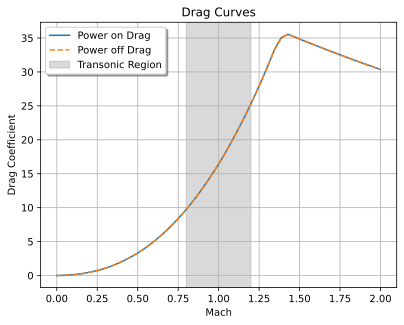


Stability Plots
--------------------


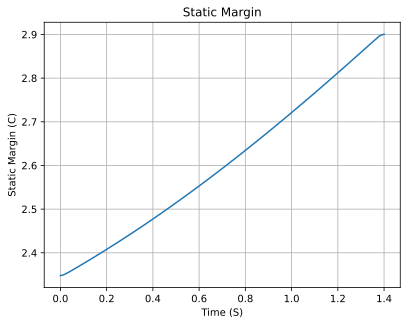

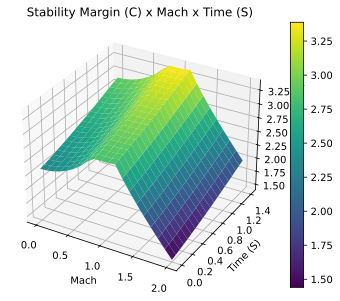


Thrust-to-Weight Plot
----------------------------------------


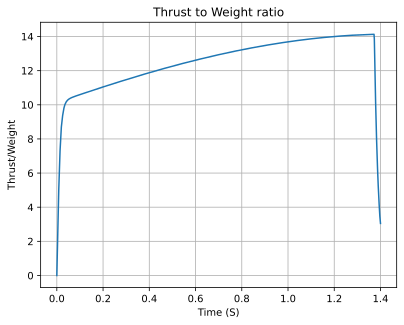

In [14]:
FalconOneRocket.all_info()

In [15]:
# %%
# ------------------------- SISTEMA DE RECUPERAÇÃO -------------------------

# Adiciona o Paraquedas Principal ao foguete
paraquedas_principal = FalconOneRocket.add_parachute(
    "ParaQuedas",       # Nome do paraquedas
    cd_s=2.3277,          # Vamos calcular juntos (Cd * Área)
    trigger="apogee",  # Acionamento no ponto mais alto do voo
    sampling_rate=500, # Taxa de amostragem do altímetro em Hz (ex: 150)
    lag=1.5,           # Atraso da ejeção em segundos (ex: 1.5)
    noise=(0, 0.1, 0.5)  # Ruído do altímetro (média, desvio_padrão, correlação)
)


In [16]:
test_flight = Flight(
    rocket=FalconOneRocket, environment=env, rail_length=4, inclination=85, heading=10
)


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 495.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.995 | e1: -0.043 | e2: 0.004 | e3: -0.087
Euler Angles - Spin φ : 0.00° | Nutation θ: -5.00° | Precession ψ: -10.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.348 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 10.00°


Rail Departure State

Rail Departure Time: 0.303 s
Rail Departure Velocity: 28.097 m/s
Rail Departure Stability Margin: 2.447 c
Rail Departure Angle of Attack: 0.000°
Rail Departure Thrust-Weight Ratio: 11.484
Rail Departure Reynolds Number: 1.473e+05


Burn out State

Burn out time: 1.400 s
Altitude at burn out: 596.168 m (ASL) | 101.168 m (AGL)
Rocket speed at burn out: 146.321 m/s
Freestream veloci

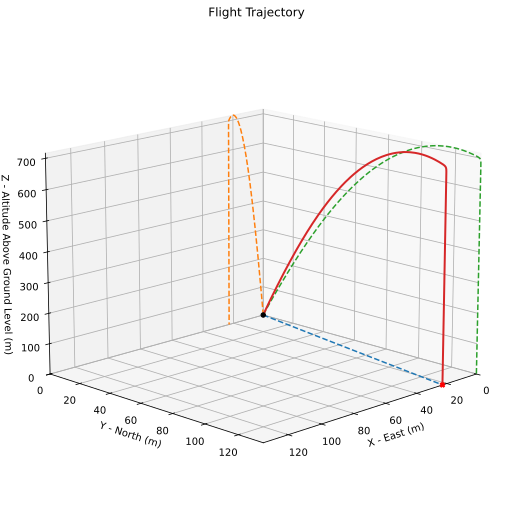



Trajectory Kinematic Plots



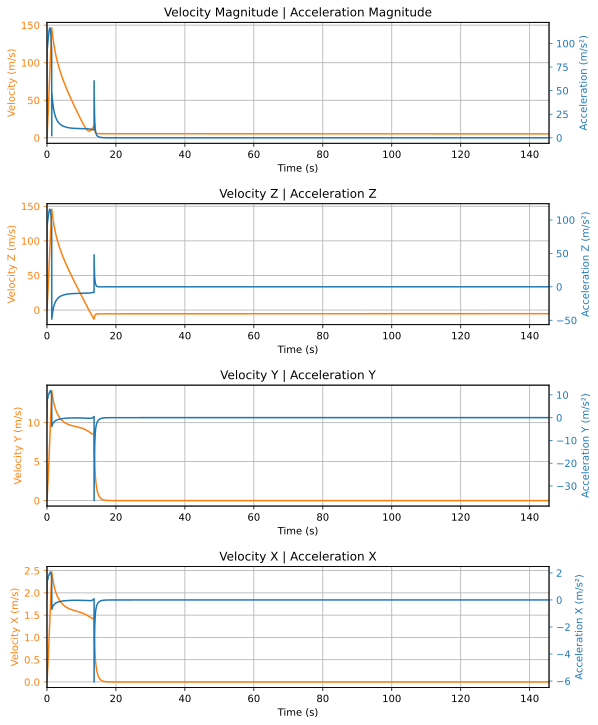



Angular Position Plots



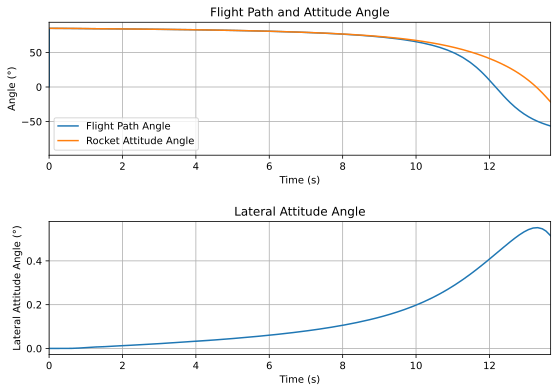



Path, Attitude and Lateral Attitude Angle plots



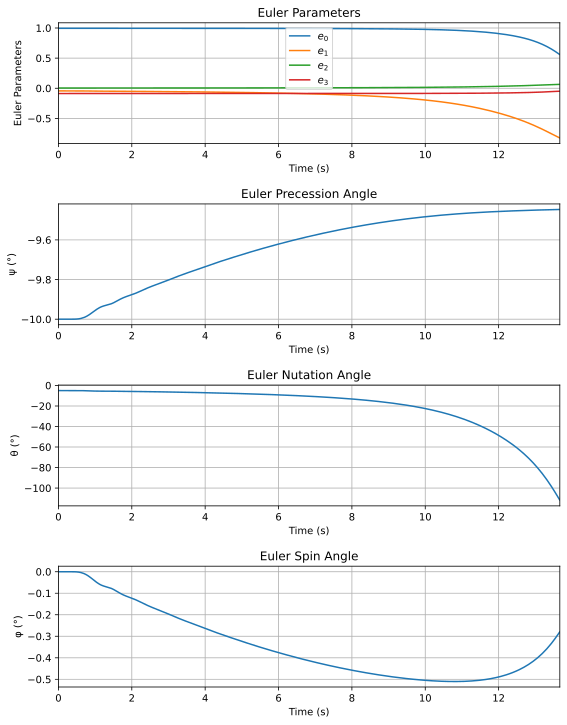



Trajectory Angular Velocity and Acceleration Plots



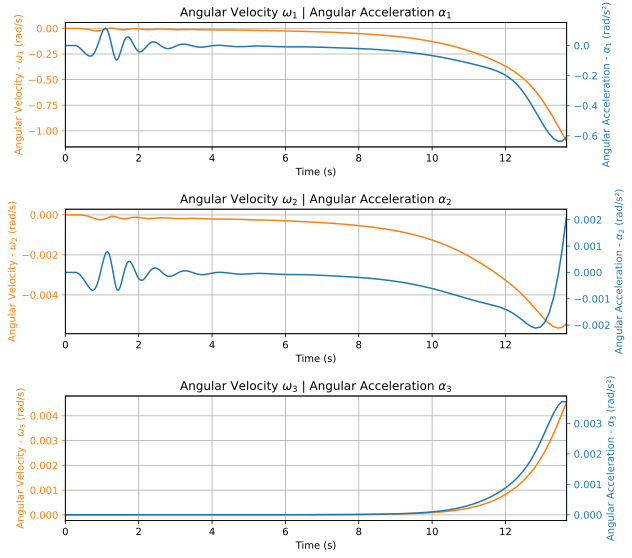



Aerodynamic Forces Plots



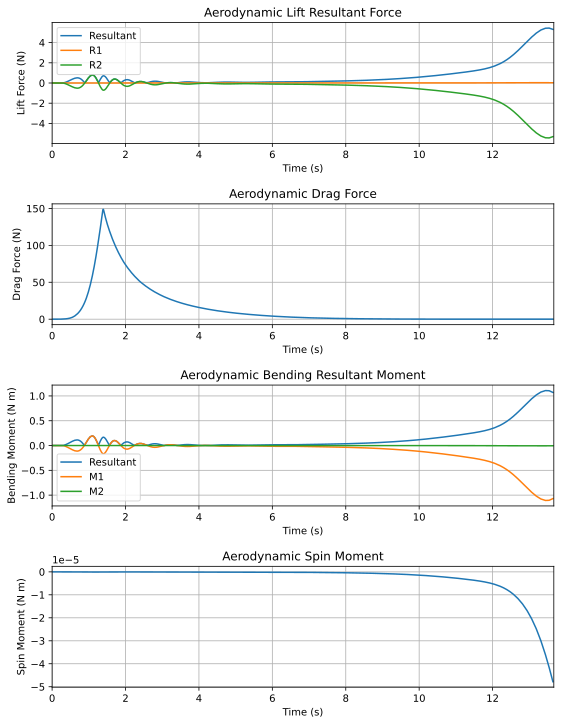



Rail Buttons Bending Moments Plots

No rail buttons were defined. Skipping rail button bending moment plots.


Rail Buttons Forces Plots

No rail buttons were defined. Skipping rail button plots.


Trajectory Energy Plots



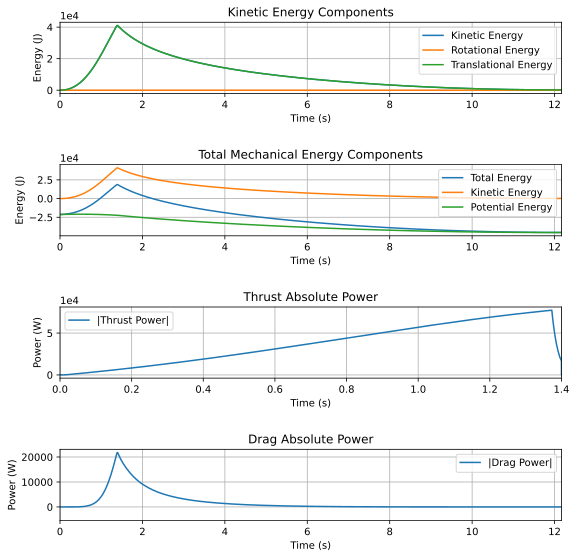



Trajectory Fluid Mechanics Plots



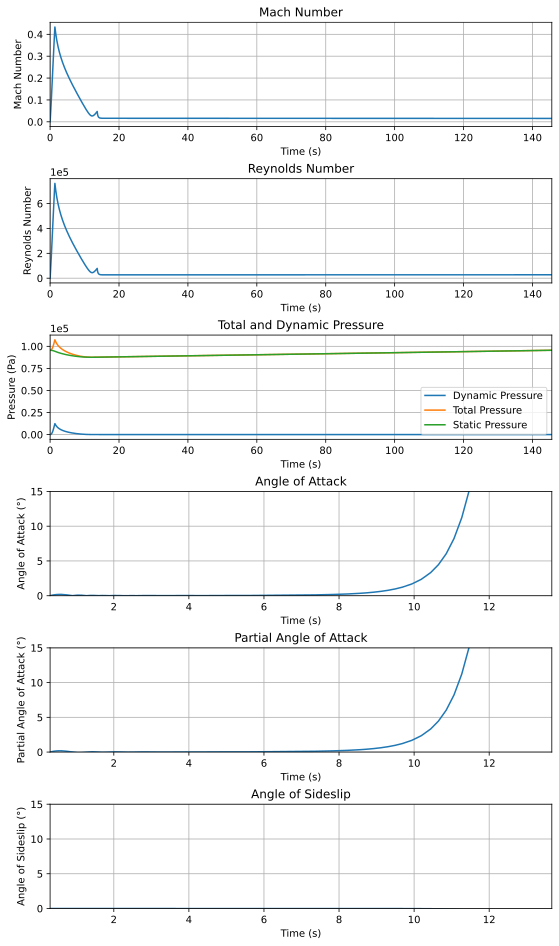



Trajectory Stability and Control Plots



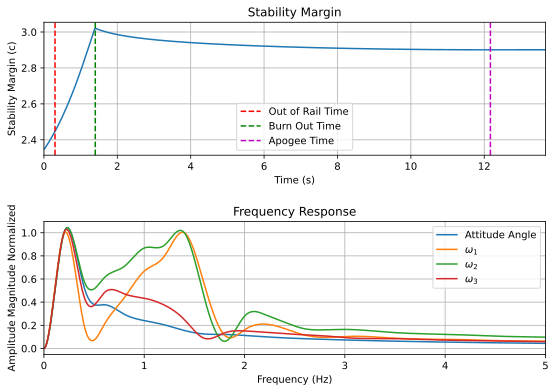



Rocket and Parachute Pressure Plots



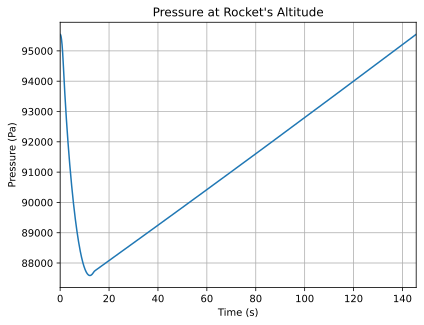


Parachute:  ParaQuedas


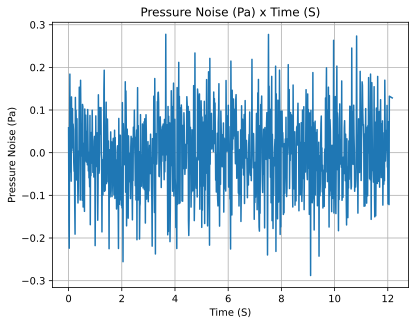

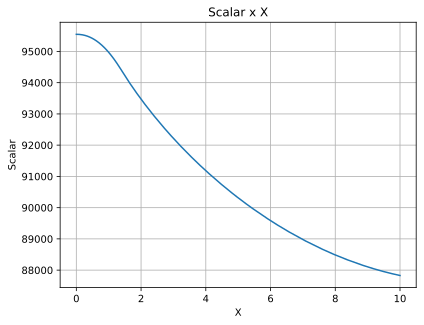

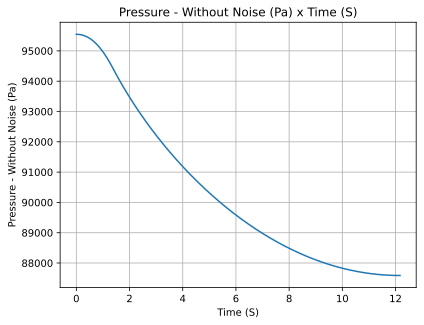

In [17]:
test_flight.all_info()

In [18]:
test_flight.export_kml(
    file_name="Lançamento-LASC2026 Teste.kml",
    extrude=True,
    altitude_mode="relative_to_ground",
)

File  Lançamento-LASC2026 Teste.kml  saved with success!


C:\Users\wesle\AppData\Local\Temp\ipykernel_9184\731287225.py:1: DeprecationWarning: Moved to FlightDataExporter.export_kml() and will be removed in v1.12.0. Use `rocketpy.simulation.flight_data_exporter.FlightDataExporter.export_kml` instead.
  test_flight.export_kml(
